<a href="https://colab.research.google.com/github/yourblandcat/mlLab/blob/main/mlwk04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
"""
PCA Laboratory Demonstration
============================
This script demonstrates Principal Component Analysis (PCA) in two ways:
  1. Implemented from scratch using NumPy (to understand the math)
  2. Using scikit-learn's PCA class (the practical, production way)

Dataset: The classic Iris dataset (4 features, 150 samples, 3 classes)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [33]:
# -----------------------------------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------------------------------
iris = load_iris()
X = iris.data                # shape (150, 4) -> 4 features
y = iris.target              # class labels (0, 1, 2)
feature_names = iris.feature_names

print("Original data shape:", X.shape)
print("Feature names:", feature_names)


Original data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [34]:
# -----------------------------------------------------------------------
# STEP 2: Standardize the data (mean = 0, std = 1)
# PCA is affected by scale, so features must be standardized first.
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std after scaling (~1):", np.round(X_scaled.std(axis=0), 3))



Mean after scaling (~0): [-0. -0. -0. -0.]
Std after scaling (~1): [1. 1. 1. 1.]


In [35]:
# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH (using NumPy)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# 1. Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance matrix:\n", np.round(cov_matrix, 3))

# 2. Compute eigenvalues and eigenvectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 3. Sort eigenvalues (and corresponding eigenvectors) in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues (sorted):", np.round(eigen_values, 3))

# 4. Compute explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# 5. Select top k eigenvectors (k=2) to form the projection matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# 6. Project the standardized data onto the new subspace
X_pca_scratch = X_scaled.dot(projection_matrix)
print("\nTransformed data shape (from scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN (practical approach)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)


PCA FROM SCRATCH

Covariance matrix:
 [[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Eigenvalues (sorted): [2.938 0.92  0.148 0.021]
Explained variance ratio: [0.73  0.229 0.037 0.005]
Cumulative variance (first 2 components): 0.958

Transformed data shape (from scratch): (150, 2)

PCA USING SCIKIT-LEARN

Explained variance ratio: [0.73  0.229]
Cumulative variance (first 2 components): 0.958
Transformed data shape (sklearn): (150, 2)


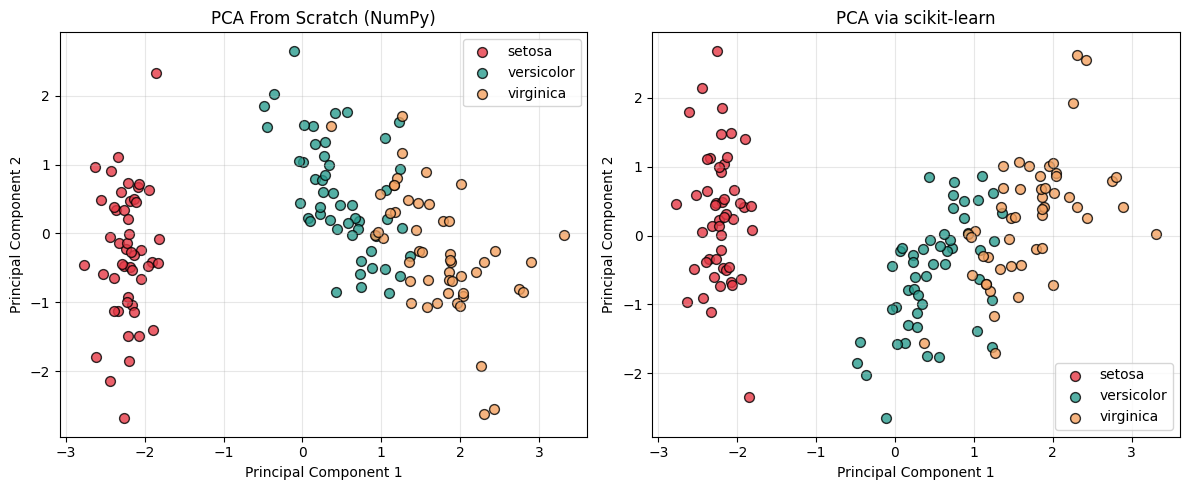

In [36]:
# -----------------------------------------------------------------------
# STEP 4: Visualize the result
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]
target_names = iris.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("/home/claude/pca_iris_result.png", dpi=150)
# print("\nPlot saved as pca_iris_result.png")

In [37]:
# -----------------------------------------------------------------------
# STEP 5: Sanity check - both methods should give (near) identical variance
# -----------------------------------------------------------------------
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")


Sanity check passed: scratch implementation matches scikit-learn.


using n_components = 3 and plotting in 3d


PCA USING SCIKIT-LEARN with n_components = 3

Explained variance ratio: [0.73  0.229 0.037]
Cumulative variance (first 3 components): 0.995
Transformed data shape (sklearn): (150, 3)


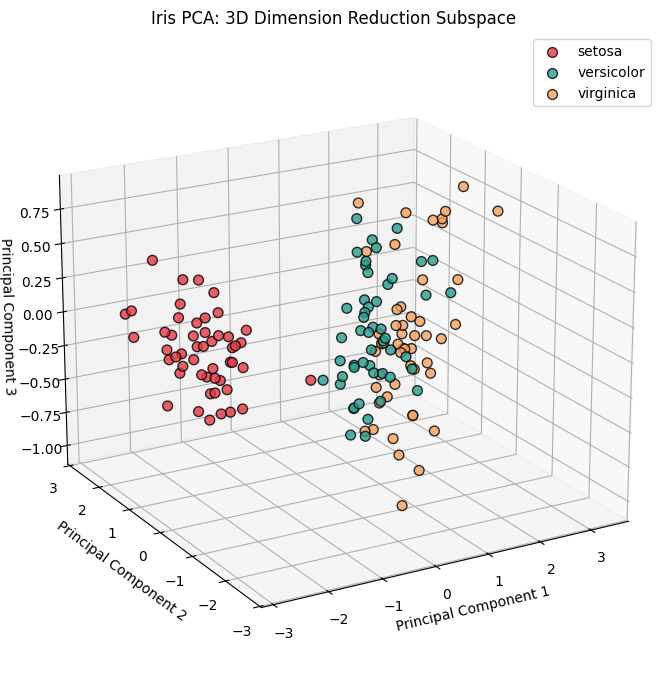

In [38]:
# -----------------------------------------------------------------------
# PCA USING SCIKIT-LEARN with n_components = 3
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN with n_components = 3")
print("=" * 60)

pca = PCA(n_components=3)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
# Fixed text description below to show "first 3 components"
print("Cumulative variance (first 3 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# 3D Visualization using Matplotlib
# -----------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

# 1. Initialize a blank canvas drawing figure
fig = plt.figure(figsize=(9, 7))

# 2. Add an active 3D drawing zone to the canvas
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 3. Define visual styles (colors and labels)
colors = ["#e63946", "#2a9d8f", "#f4a261"]
target_names = iris.target_names

# 4. Loop through each iris species group and scatter the points
for i, target_name in enumerate(target_names):
    ax.scatter(
        X_pca_sklearn[y == i, 0],  # X-axis: 1st Principal Component
        X_pca_sklearn[y == i, 1],  # Y-axis: 2nd Principal Component
        X_pca_sklearn[y == i, 2],  # Z-axis: 3rd Principal Component
        label=target_name,
        color=colors[i],
        alpha=0.8,
        edgecolor="k",
        s=50
    )

# 5. Set text labels for all three dimensions
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("Iris PCA: 3D Dimension Reduction Subspace")

# 6. Adjust the virtual camera viewing angle
ax.view_init(elev=20, azim=-120)

# 7. Add a legend map and save the figure
ax.legend()
plt.tight_layout()
# plt.savefig("pca_iris_3d_mplot3d.png", dpi=150)
# print("\n3D Plot saved successfully!")

PCA without standardizing the data


PCA WITHOUT STANDARDIZATION (UNSCALED RAW DATA)
Explained variance ratio: [0.925 0.053]
Cumulative variance: 0.978


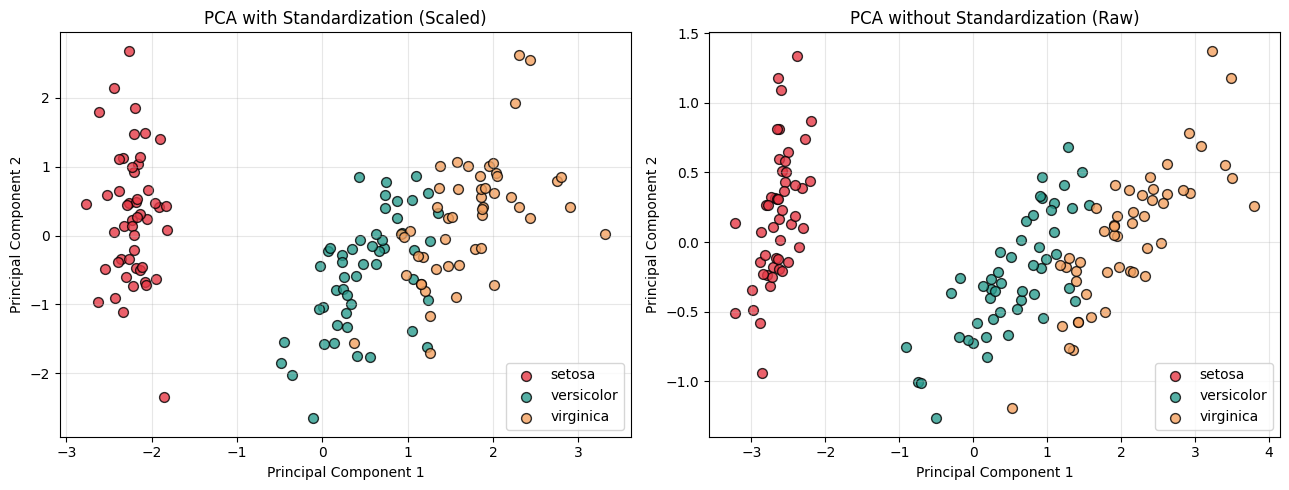

In [39]:
# 1. Load the core dataset variables
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. CREATE THE MISSING VARIABLE: Scale the data and run Scaled PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)  # <-- This defines X_pca_scaled!

# 3. Run the Unscaled PCA
print("=" * 60)
print("PCA WITHOUT STANDARDIZATION (UNSCALED RAW DATA)")
print("=" * 60)
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

print("Explained variance ratio:", np.round(pca_raw.explained_variance_ratio_, 3))
print("Cumulative variance:", np.round(np.sum(pca_raw.explained_variance_ratio_), 3))

# 4. Visualize the side-by-side structural differences
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]

# Loop over the two distinct transformed datasets
for ax, data, title in zip(
    axes,
    [X_pca_scaled, X_pca_raw],
    ["PCA with Standardization (Scaled)", "PCA without Standardization (Raw)"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()  # Displays the plot immediately on screen

Digits dataset

In [40]:
from sklearn.datasets import load_digits

# 1. Load the Digits dataset (1797 samples, 64 features per image)
digits = load_digits()
X = digits.data

# 2. Standardize the data (Mean = 0, Std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit PCA keeping ALL possible components
pca = PCA()  # Leaving n_components blank defaults to keeping all 64
pca.fit(X_scaled)

# 4. Compute the running total (cumulative sum) of explained variance
# np.cumsum([1, 2, 3]) results in [1, 1+2, 1+2+3] -> [1, 3, 6]
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 5. Find where the cumulative variance crosses the 90% (0.90) threshold
# np.argmax returns the index of the FIRST value that satisfies the condition
target_variance = 0.90
min_components = np.argmax(cumulative_variance >= target_variance) + 1

# -----------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------
print("=" * 60)
print(f"PCA TARGET: {target_variance * 100}% CUMULATIVE VARIANCE")
print("=" * 60)
print(f"Total available features (dimensions): {X.shape[1]}")
print(f"Minimum components needed: {min_components}")
print(f"Exact variance retained with {min_components} components: {cumulative_variance[min_components - 1]:.4f}")

PCA TARGET: 90.0% CUMULATIVE VARIANCE
Total available features (dimensions): 64
Minimum components needed: 31
Exact variance retained with 31 components: 0.9005


custom csv with missing values

--- Raw Input Data (X) ---
    age   income  credit_score subscription_type
0  34.0  58000.0         680.0           Premium
1  45.0  82000.0         710.0             Basic
2  22.0  31000.0         590.0              Free
3  50.0      NaN         790.0           Premium
4  28.0  42000.0           NaN             Basic

PIPELINE EXECUTION STATISTICS
Explained Variance Ratio per component: [0.796 0.109]
Total Cumulative Variance retained: 0.905
Final Matrix Shape after reduction: (10, 2)


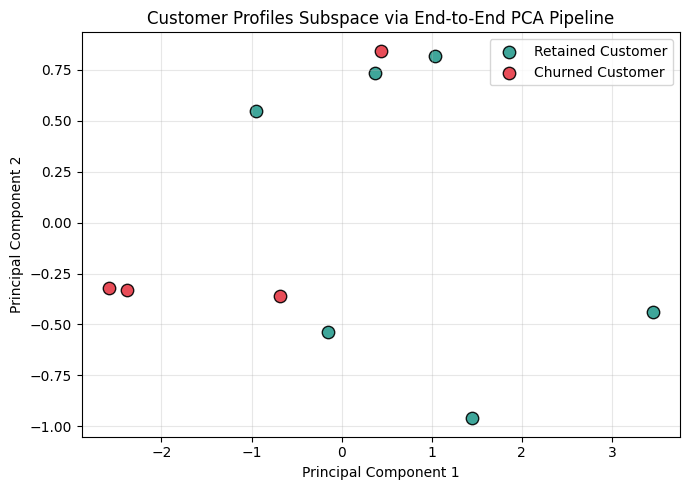

In [41]:
# =======================================================================
# STEP 1: Create and Load a Mock Messy CSV Dataset
# =======================================================================
csv_data = """customer_id,age,income,credit_score,subscription_type,churned
101,34,58000.0,680,Premium,0
102,45,82000.0,710,Basic,0
103,22,31000.0,590,Free,1
104,50,,790,Premium,0
105,28,42000.0,,Basic,0
106,61,112000.0,820,Premium,0
107,,52000.0,640,Free,1
108,39,69000.0,700,,0
109,42,75000.0,670,Basic,1
110,25,28000.0,550,Free,1
"""

# Load the CSV data using pandas
df = pd.read_csv(io.StringIO(csv_data))

# Separate our independent features (X) from the dependent target label (y)
X = df.drop(columns=["customer_id", "churned"])
y = df["churned"]

print("--- Raw Input Data (X) ---")
print(X.head())

# =======================================================================
# STEP 2: Construct the Preprocessing + PCA Pipeline Architecture
# =======================================================================

# 1. Identify which columns belong to which data type group
numeric_features = ["age", "income", "credit_score"]
categorical_features = ["subscription_type"]

# 2. Define the cleanup assembly line for NUMERIC values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Fill missing with median
    ("scaler", StandardScaler())                  # Scale mean=0, std=1
])

# 3. Define the cleanup assembly line for CATEGORICAL strings
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Fill missing with mode
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # Convert to numbers
])

# 4. Use ColumnTransformer to execute both cleaning paths simultaneously
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 5. Build the final end-to-end master pipeline including PCA
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=2))
])

# =======================================================================
# STEP 3: Execute the Pipeline
# =======================================================================
# Fit the cleaning rules and transform the data down to 2 dimensions all at once
X_pca = full_pipeline.fit_transform(X)

print("\n" + "=" * 50)
print("PIPELINE EXECUTION STATISTICS")
print("=" * 50)
# Extract the trained PCA stage out of our pipeline structure to inspect values
pca_stage = full_pipeline.named_steps["pca"]
print("Explained Variance Ratio per component:", np.round(pca_stage.explained_variance_ratio_, 3))
print("Total Cumulative Variance retained:", np.round(np.sum(pca_stage.explained_variance_ratio_), 3))
print("Final Matrix Shape after reduction:", X_pca.shape)

# =======================================================================
# STEP 4: Visualize the clean customer profiles
# =======================================================================
plt.figure(figsize=(7, 5))
colors = ["#2a9d8f", "#e63946"]
labels = ["Retained Customer", "Churned Customer"]

for class_val, color, label in zip([0, 1], colors, labels):
    plt.scatter(
        X_pca[y == class_val, 0], X_pca[y == class_val, 1],
        color=color, label=label, s=80, edgecolor="k", alpha=0.9
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Profiles Subspace via End-to-End PCA Pipeline")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()